# Week 7 - Milestone One week

# 1. Lesson: no lesson this week.  Milestone One is due!

# 2. Weekly graph question

Below are the graphs from last week's weekly graph question.  Suppose you wanted to cause the viewer to examine the last three months of data first.  How could you use preattentive attributes to do that?  Suggest several possibilities.

In [62]:
import numpy as np
import seaborn as sns
import pandas as pd

Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

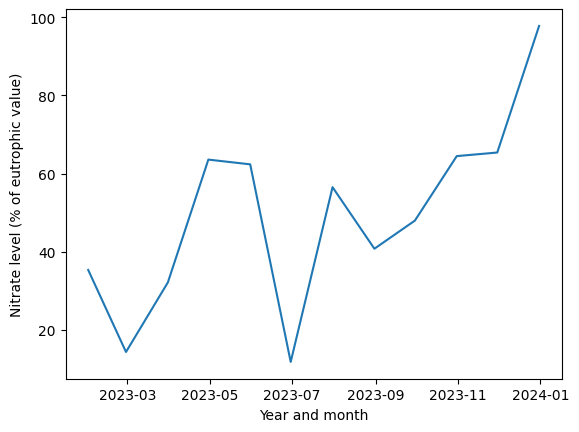

In [63]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='ME')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

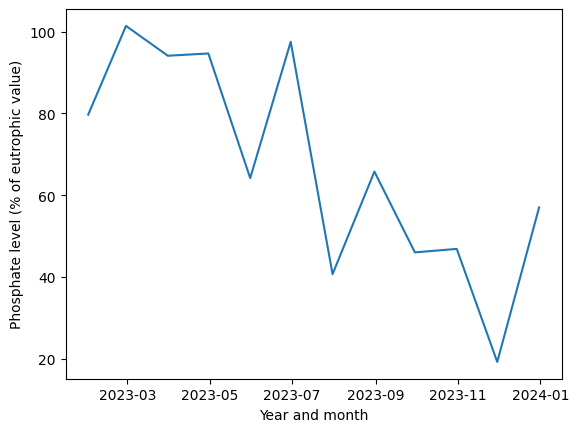

In [64]:
np.random.seed(1)
time_series = 100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='ME')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

# 3. Working on your datasets

This week, you can work on Milestone One rather than having a particular exercise about working on your datasets

In [65]:
#Using this space to do some analyses for a second dataset. 

In [66]:
pip install openpyxl


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [67]:
import pandas as pd

df = pd.read_excel("Cancer Over Time.xlsx")

df.head()

,Population,Number,Coverage,0,5,10,15,20,25,30,...,40,45,50,55,60,65,70,75,80,85
0,Belarus,9645186,1.000,500139,491780,553471,652503,722133,736547,706434,...,723377,728719,694797,584389,493514,421309,368767,297270,171250,102524
1,Canada*,24678472,0.745,1364347,1428536,1506576,1625091,1705141,1700674,1717339,...,1870100,1887673,1805820,1572796,1294395,1040418,822975,652733,476267,430750
2,Chile*,378973,0.022,27411,29644,32235,33314,30643,27447,25814,...,26802,25668,22438,18490,15433,12367,9706,7188,7994,0
3,Croatia,4343096,1.000,213340,227736,242169,262681,280303,294028,297579,...,302914,311267,314675,290401,259506,230712,202986,161566,98524,53791
4,Cyprus*,794835,0.715,45432,47337,50763,57417,63511,63684,60248,...,55439,53480,50590,45689,39891,33856,26721,20299,13272,10007


In [68]:
df1 = pd.read_excel("Cancer Over Time.xlsx", sheet_name="USA By Year")
df2 = pd.read_excel("Cancer Over Time.xlsx", sheet_name="Populations")

In [69]:
df1_long = df.melt(
    id_vars=["Year", "Number"],
    var_name="Age_Group",
    value_name="Cancer_Cases"
)

df1_long.head()

KeyError: "The following id_vars or value_vars are not present in the DataFrame: ['Year']"

In [ ]:
df1_long["Age_Group"] = df1_long["Age_Group"].astype(int)

In [ ]:
df1_long.describe()

,Year,Number,Age_Group,Cancer_Cases
count,324.000000,3.240000e+02,324.000000,3.240000e+02
mean,2008.500000,2.492285e+07,42.500000,1.384603e+06
std,5.196152,7.682971e+05,25.980762,5.000849e+05
min,2000.000000,2.382442e+07,0.000000,3.645560e+05
25%,2004.000000,2.414544e+07,20.000000,9.091922e+05
50%,2008.500000,2.489878e+07,42.500000,1.647786e+06
75%,2013.000000,2.561398e+07,65.000000,1.734167e+06
max,2017.000000,2.619336e+07,85.000000,1.965889e+06


In [ ]:
df1_long.head()

,Year,Number,Age_Group,Cancer_Cases
0,2000,23824419,0,1630833
1,2001,23958580,0,1636071
2,2002,24020515,0,1633728
3,2003,24071193,0,1636011
4,2004,24145436,0,1639508


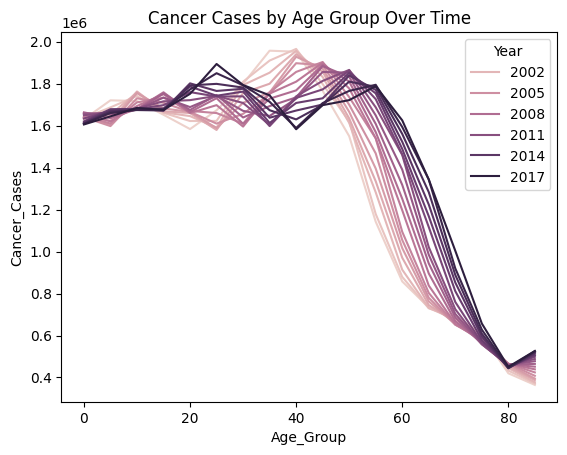

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(
    data=df_long,
    x="Age_Group",
    y="Cancer_Cases",
    hue="Year"
)

plt.title("Cancer Cases by Age Group Over Time")
plt.show()

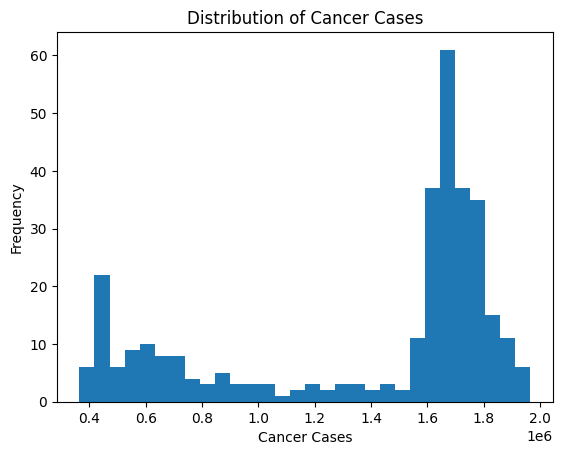

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df1_long["Cancer_Cases"], bins=30)
plt.title("Distribution of Cancer Cases")
plt.xlabel("Cancer Cases")
plt.ylabel("Frequency")
plt.show()

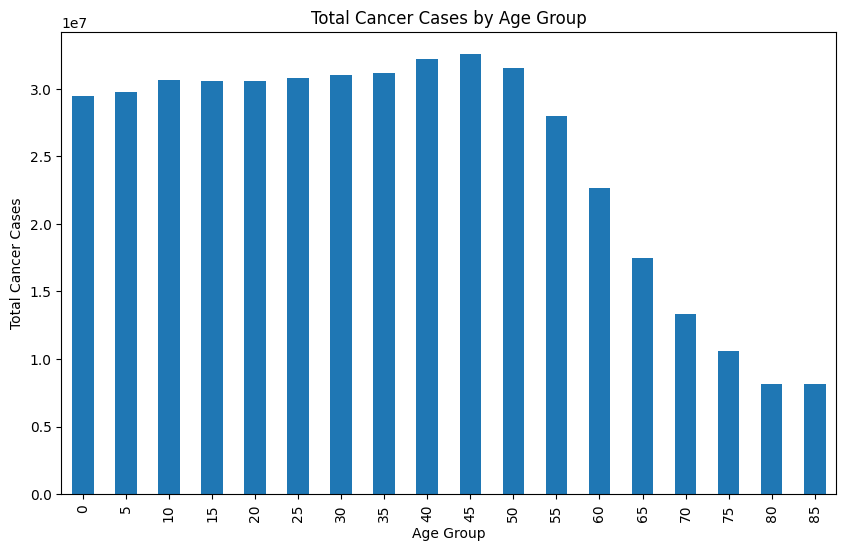

In [ ]:
import matplotlib.pyplot as plt

age_totals = df1_long.groupby("Age_Group")["Cancer_Cases"].sum()


age_totals.plot(kind="bar", figsize=(10,6))

plt.title("Total Cancer Cases by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Cancer Cases")
plt.show()

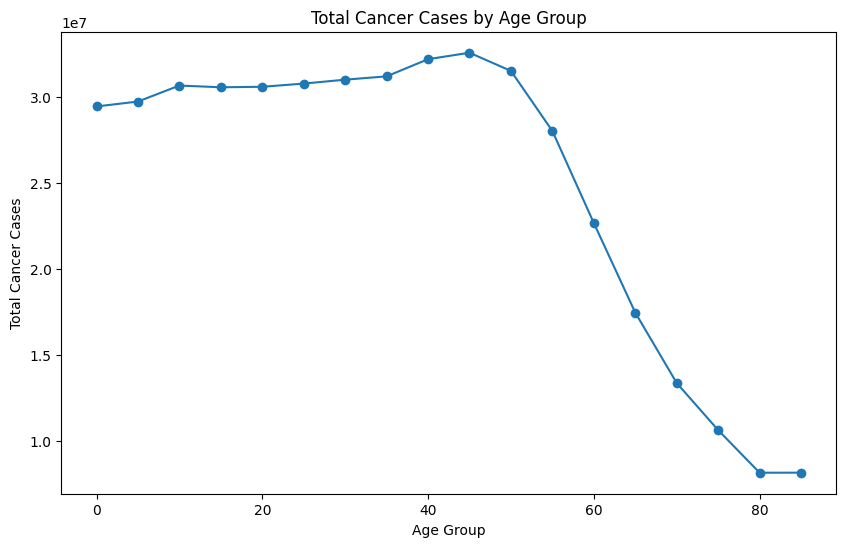

In [ ]:
age_totals.plot(figsize=(10,6), marker="o")

plt.title("Total Cancer Cases by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Cancer Cases")
plt.show()

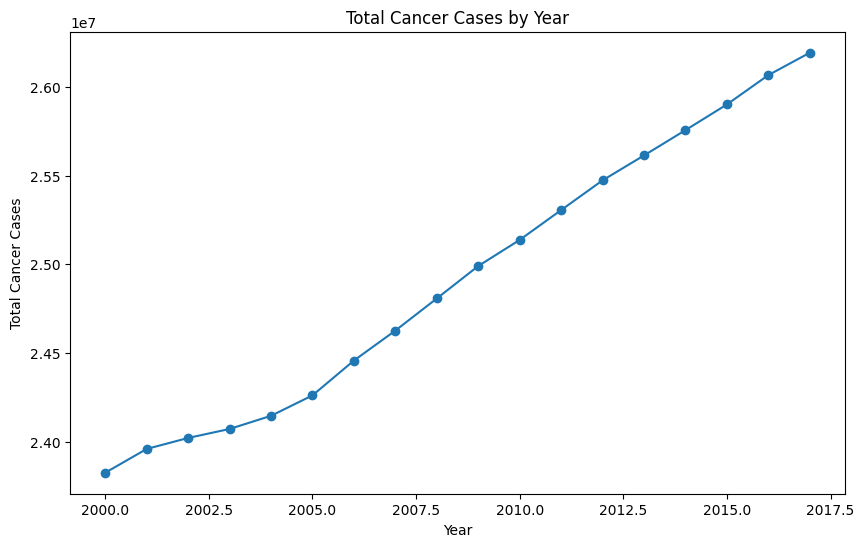

In [ ]:
year_totals = df1_long.groupby("Year")["Cancer_Cases"].sum()

year_totals.plot(figsize=(10,6), marker="o")

plt.title("Total Cancer Cases by Year")
plt.xlabel("Year")
plt.ylabel("Total Cancer Cases")
plt.show()

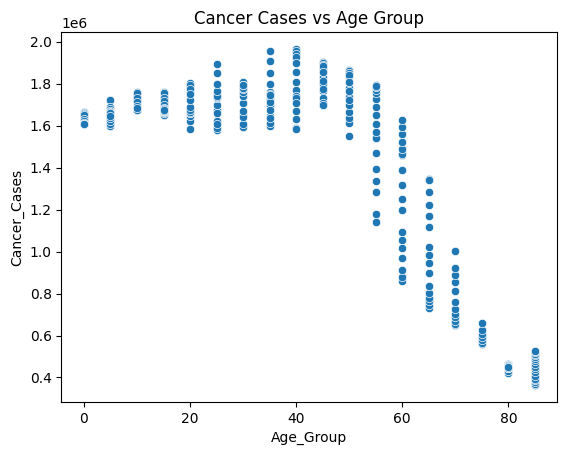

In [ ]:
sns.scatterplot(
    data=df1_long,
    x="Age_Group",
    y="Cancer_Cases"
)

plt.title("Cancer Cases vs Age Group")
plt.show()

In [ ]:
pivot_table = df1_long.pivot_table(
    values="Cancer_Cases",
    index="Age_Group",
    columns="Year",
    aggfunc="sum"
)

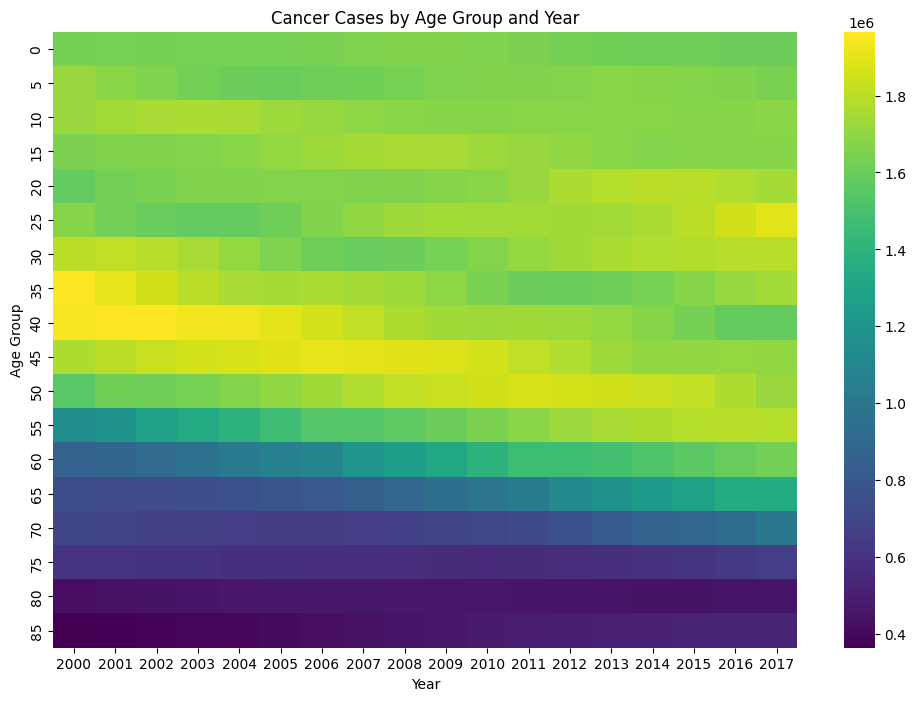

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    pivot_table,
    cmap="viridis"
)

plt.title("Cancer Cases by Age Group and Year (USA)")
plt.xlabel("Year")
plt.ylabel("Age Group")

plt.show()

In [ ]:
#Repeat Heatmap for BRazil Dataset

import os
import zipfile
import tempfile

# create temporary directory (not inside repo)
temp_dir = tempfile.gettempdir()
data_dir = os.path.join(temp_dir, "brazil_cancer_data")

os.makedirs(data_dir, exist_ok=True)

zip_path = os.path.join(data_dir, "cancer-data-brazil.zip")
csv_path = os.path.join(data_dir, "cancer_data_eng.csv")

# download if not already present
if not os.path.exists(csv_path):

    os.system(f"kaggle datasets download joaopedromedeiros/cancer-data-brazil -p {data_dir}")

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(data_dir)

df_brazil = pd.read_csv(csv_path, encoding="ISO-8859-1")

/tmp/ipykernel_8284/1424595474.py:24: DtypeWarning: Columns (0: Date.of.Birth, 1: Raca.Color, 2: Nationality, 3: Naturality.State, 4: Naturality, 5: Degree.of.Education, 6: State.Civil, 7: Status.Address, 8: City.Address, 9: Youth.Adult.Illness.Description, 10: Code.of.Disease.Adult.Young., 11: Indicator.of.Rare.Case, 12: Extension, 13: Laterality, 14: Statement, 15: TNM, 16: Status.Vital, 17: Type.of.Death, 18: Date.of.Death, 19: Date.of.Last.Contact, 20: Date.of.Diagnostic, 21: Distant.metastasis) have mixed types. Specify dtype option on import or set low_memory=False.
  df_brazil = pd.read_csv(csv_path, encoding="ISO-8859-1")


In [ ]:
#Recall data cleaning efforts from week 4.  

df_brazil["Date.of.Birth"] = pd.to_datetime(df["Date.of.Birth"], errors="coerce")
df_brazil["Date.of.Diagnostic"] = pd.to_datetime(df["Date.of.Diagnostic"], errors="coerce")

df_brazil.loc[df["Age"] >= 116, "Age"] = None
df_brazil.loc[df["Age"] <= 0, "Age"] = None


df_brazil.loc[
    df_brazil["Date.of.Birth"].isna() & df_brazil["Age"].notna(),
    "Date.of.Birth"
] = df_brazil["Date.of.Diagnostic"] - pd.to_timedelta(df["Age"] * 365.25, unit="D")

df_brazil[["Age", "Date.of.Birth"]].isnull().sum()

columns_encode = [
    "Gender",
    "Raca.Color",
    "Nationality",
    "Degree.of.Education",
    "State.Civil",
    "Status.Address",
    "Indicator.of.Rare.Case",
    "Diagnostic.means",
    "Extension",
    "Laterality",
    "Statement",
    "Status.Vital",
    "Type.of.Death",
]

df_brazil_encoded = pd.get_dummies(df, columns=columns_encode, drop_first=True)

/usr/local/python/3.12.1/lib/python3.12/site-packages/pandas/core/arrays/timedeltas.py:1163: RuntimeWarning: invalid value encountered in cast
  int_data = data.astype(np.int64)


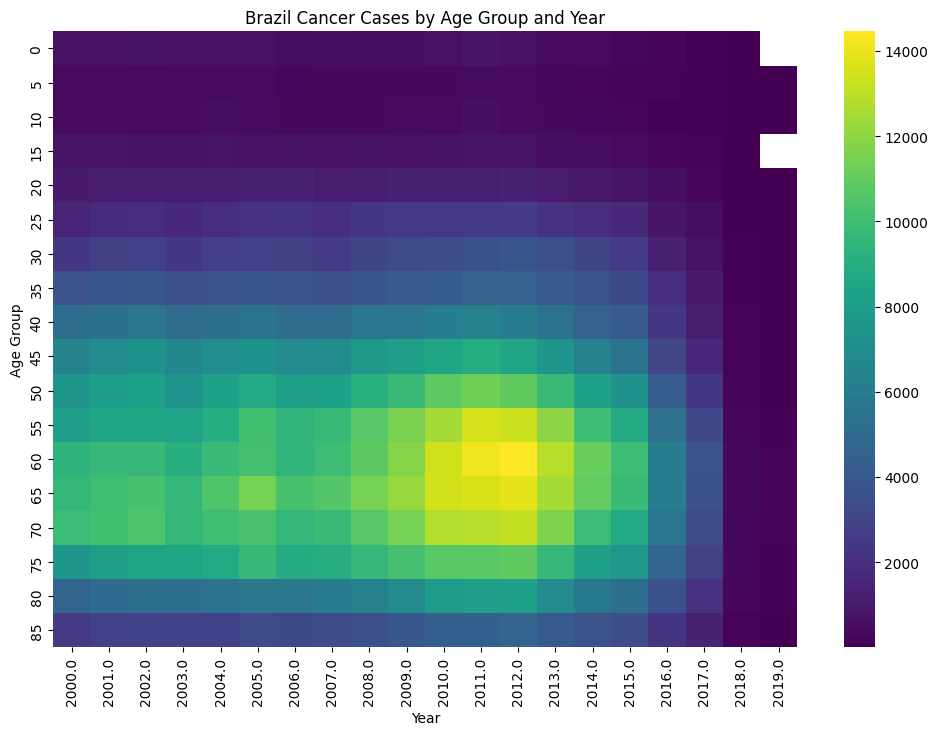

In [ ]:
import pandas as pd

bins = list(range(0, 95, 5))
labels = bins[:-1]

df_brazil["Age_Group"] = pd.cut(
    df_brazil["Age"],
    bins=bins,
    labels=labels,
    right=False
)

age_year_counts = df_brazil.groupby(["Age_Group", "year"]).size().reset_index(name="Cancer_Cases")

pivot_brazil = age_year_counts.pivot(
    index="Age_Group",
    columns="year",
    values="Cancer_Cases"
)



plt.figure(figsize=(12,8))

sns.heatmap(
    pivot_brazil,
    cmap="viridis"
)

plt.title("Brazil Cancer Cases by Age Group and Year")
plt.xlabel("Year")
plt.ylabel("Age Group")

plt.show()


# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 99-119 of the Storytelling With Data book as best you can. (The first half of chapter four). You do not have to get the exact data values right, just the overall look and feel.